> **Note:** This notebook depends on variables created in `01_cleaning.ipynb` (`combined_df`, `model_df`, neighbourhood sub-DataFrames). Run that notebook first in the same session, or re-paste the cleaning cells here.

# 3. Exploratory Data Analysis

**Revenue Distribution**

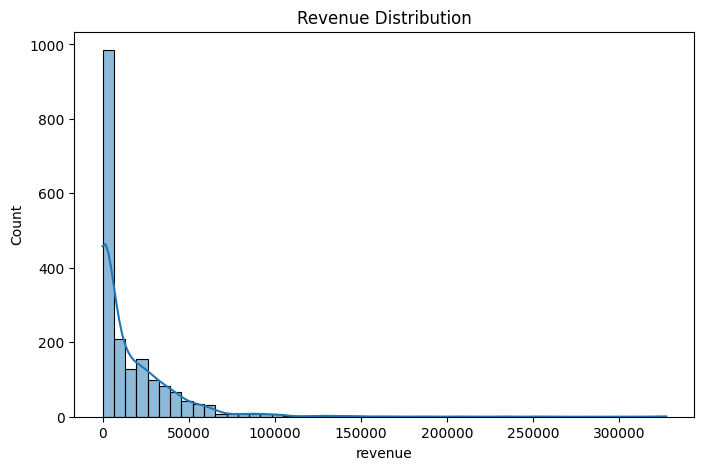

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(combined_df['revenue'], bins=50, kde=True)
plt.title("Revenue Distribution")
plt.show()

The revenue distribution is highly right-skewed, which is typical for Airbnb markets. Most listings earn between  5,000− 50,000 per year, while a smaller group reaches  50,000− 100,000. A few luxury homes generate more than $150,000, creating a long right tail.

The skew suggests that median revenue is more representative than the mean. High-revenue outliers are expected and usually correspond to premium properties in neighborhoods such as Hollywood Hills or Pasadena.

**Revenue Distribution by neighbourhood**

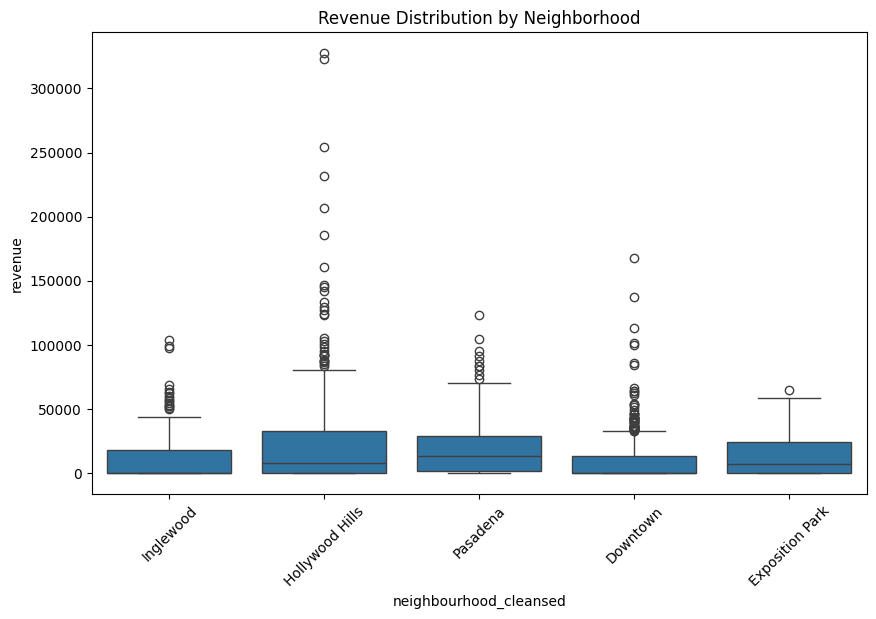

In [ ]:
# Box-plot for revenue distribution per neighbourhood
plt.figure(figsize=(10,6))
sns.boxplot(data=combined_df, x="neighbourhood_cleansed", y="revenue")
plt.xticks(rotation=45)
plt.title("Revenue Distribution by Neighborhood")
plt.show()

This plot further breaks down revenue distribution to a per-neighborhood basis. We see that Hollywood Hills, Pasadena, and Exposition Park all have similar median revenues, while Inglewood and Downtown have similar lower median revenues. One thing to note is that Hollywood Hills has many outliers above the 4th quartile, while Exposition Park only has one. Since outliers do not affect the median, this could indicate that Exposition Park's properties are more concentrated around the median level, while Hollywood Hills has distribution is more spread out. Hollywood Hills reaches the same median as Pasadena and Exposition Park, but with far greater variability and a long tail of high-earning properties.

**Average Revenue by Neighborhood**

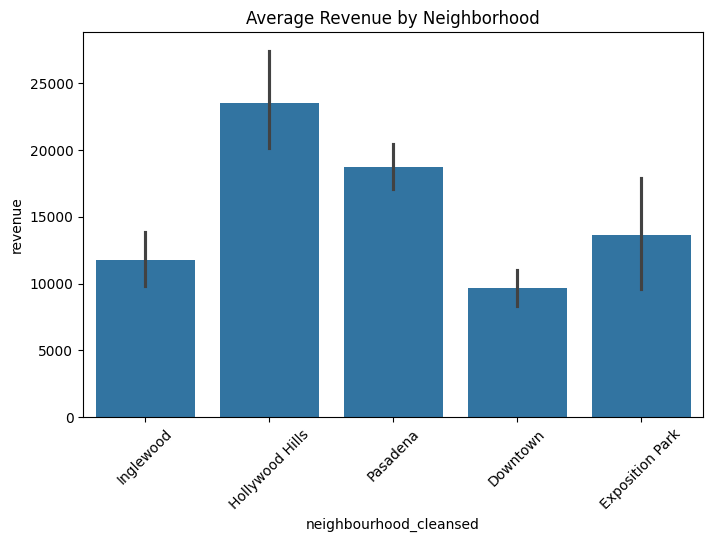

In [ ]:
#Average Revenue by Neighborhood
plt.figure(figsize=(8,5))
sns.barplot(data=combined_df, x="neighbourhood_cleansed", y="revenue", estimator=np.mean)
plt.title("Average Revenue by Neighborhood")
plt.xticks(rotation=45)
plt.show()

This chart shows the average revenue for each neighborhood, and the error bars help us understand how much variation there is inside each area.
Hollywood Hills has the widest error bars, which means revenue there can change a lot from one property to another. Some homes earn very high amounts, while others earn much less.
Exposition Park has a similar average revenue, but its error bars are smaller. This tells us that most properties earn closer to the same amount, the neighborhood is more stable and predictable.
In contrast, Downtown and Inglewood not only have lower average revenue, but also smaller variability, meaning there are fewer high-earning properties there.



**Scatterplot: price per night vs revenue based on neighbourhood**

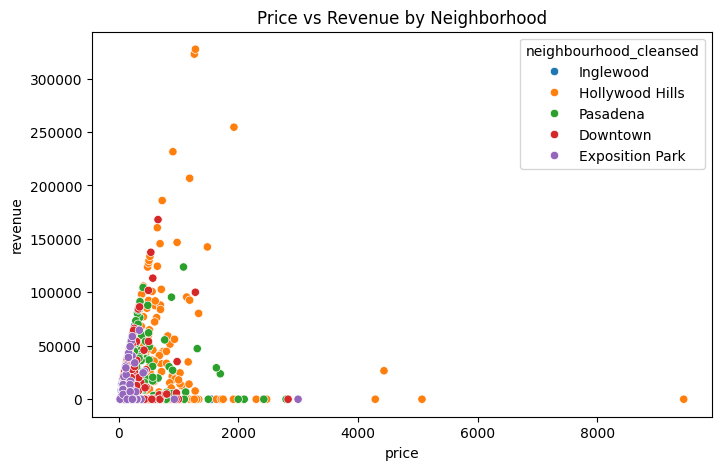

In [ ]:

#This scatter plot shows the relationship
#between nightly price and estimated annual revenue across the selected Los Angeles neighborhoods.
plt.figure(figsize=(8,5))
sns.scatterplot(data=combined_df, x="price", y="revenue", hue="neighbourhood_cleansed")
plt.title("Price vs Revenue by Neighborhood")
plt.show()

This scatter plot shows the relationship between price and annual revenue across neighborhoods.
There is a clear upward trend: higher-priced listings tend to generate higher revenue, although the relationship is not perfectly linear. Hollywood Hills displays the highest-revenue outliers, while the other neighborhoods remain within lower and more compact ranges. This suggests that both price level and neighborhood significantly influence earning.

**Pirce distribution per neighbourhood**

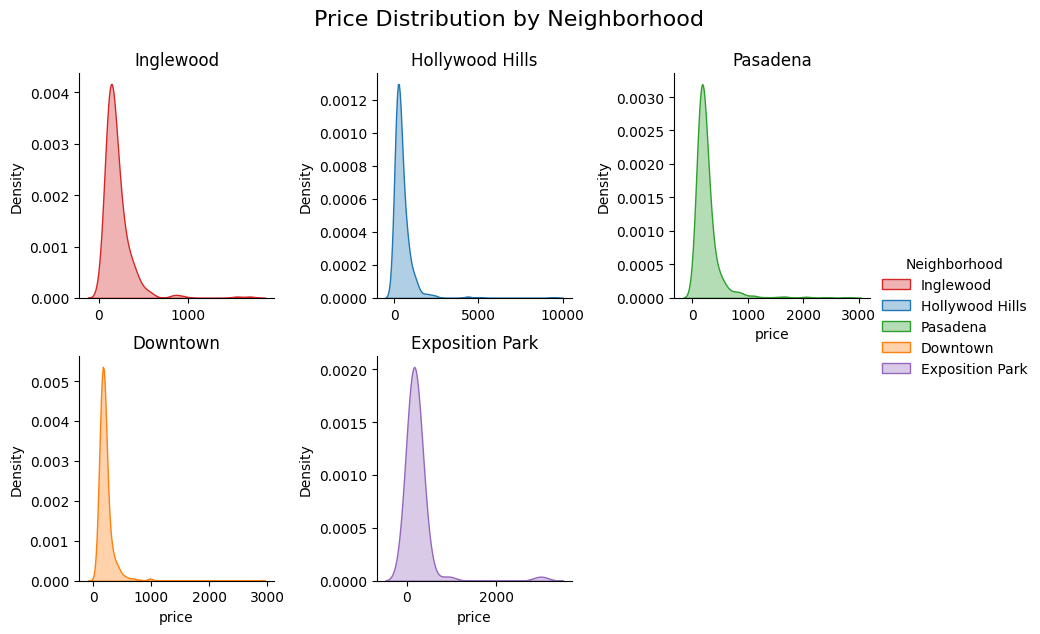

In [ ]:
# colour palatte
palette = {
    "Hollywood Hills": "#1f77b4",
    "Downtown":        "#ff7f0e",
    "Pasadena":        "#2ca02c",
    "Inglewood":       "#d62728",
    "Exposition Park": "#9467bd"
}

g = sns.FacetGrid(
    combined_df,
    col="neighbourhood_cleansed",
    hue="neighbourhood_cleansed",
    col_wrap=3,
    palette=palette,
    sharex=False,
    sharey=False
)

# Plot KDE
g.map(sns.kdeplot, "price", fill=True, alpha=0.35, linewidth=1)

# Remove the long default titles and replace with clean neighborhood names
for ax, title in zip(g.axes.flatten(), g.col_names):
    ax.set_title(title.replace("neighbourhood_cleansed = ", ""))

g.fig.suptitle("Price Distribution by Neighborhood", y=1.05, fontsize=16)

g.add_legend(title="Neighborhood")

plt.show()

The charts offer a clear visual comparison of nightly prices in major Los Angeles neighborhoods.

Hollywood Hills exhibits the highest price distribution, due to the presence of premium and luxury properties. Downtown and Inglewood show much lower and more concentrated price distributions, reflecting more affordable markets with less variability. Pasadena and Exposition Park fall somewhere in between, offering moderate price ranges with a relatively balanced distribution.

These patterns confirm that location plays a significant role in shaping Airbnb prices and that upscale neighborhoods have significantly higher nightly rates.